# 07 - Modèle SVM

## Objectif

Entraîner un modèle SVM à partir des caractéristiques extraites et évaluer ses performances sur le jeu de test.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd

from src.evaluation import classification_report_dataframe, compute_metrics, plot_confusion_matrix, save_dataframe, save_metrics
from src.ml_models import prepare_xy, save_model, train_svm
from src.utils import FEATURES_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR

## 1. Chargement du dataset de caractéristiques

Ce fichier est créé dans le notebook 06.

In [2]:
features_path = FEATURES_DIR / "casting_features.csv"
if not features_path.exists():
    raise FileNotFoundError("Lancez d'abord le notebook 06 pour générer data/features/casting_features.csv")

features_df = pd.read_csv(features_path)
display(features_df.head())
display(features_df.groupby(["split", "label_name"]).size().reset_index(name="count"))

,intensity_mean,intensity_std,intensity_min,intensity_max,intensity_median,intensity_p10,intensity_p90,hist_00,hist_01,hist_02,...,defect_area,defect_area_ratio,largest_defect_area,largest_defect_area_ratio,path,filename,split,class_folder,label,label_name
0,156.107742,62.096371,3.0,253.0,172.0,43.0,223.0,0.019944,0.046189,0.050100,...,14998.0,0.166644,11467.0,0.127411,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1.jpeg,train,ok_front,0,OK
1,157.017288,58.785080,3.0,253.0,176.0,50.0,213.0,0.021233,0.039978,0.034711,...,26201.0,0.291122,12151.0,0.135011,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1001.jpeg,train,ok_front,0,OK
2,149.712479,58.804409,2.0,249.0,168.0,41.0,204.0,0.029444,0.046744,0.038456,...,25808.0,0.286756,10709.0,0.118989,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1002.jpeg,train,ok_front,0,OK
3,155.423035,62.106228,4.0,254.0,170.0,42.0,224.0,0.019167,0.043589,0.055267,...,15455.0,0.171722,11481.0,0.127567,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1003.jpeg,train,ok_front,0,OK
4,161.378815,61.426872,4.0,251.0,183.0,57.0,225.0,0.016300,0.032667,0.033989,...,31703.0,0.352256,19389.0,0.215433,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1005.jpeg,train,ok_front,0,OK


,split,label_name,count
0,test,Defective,453
1,test,OK,262
2,train,Defective,3758
3,train,OK,2875


## 2. Préparation de X et y

Le train sert à apprendre le modèle. Le test sert uniquement à mesurer la performance finale.

In [3]:
X_train, y_train, feature_columns = prepare_xy(features_df, split="train")
X_test, y_test, _ = prepare_xy(features_df, split="test", feature_columns=feature_columns)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (6633, 50)
X_test: (715, 50)


## 3. Entraînement du SVM

Le pipeline contient une normalisation (`StandardScaler`) suivie d'un SVM à noyau RBF.

In [4]:
model = train_svm(X_train, y_train, kernel="rbf", c=10.0, gamma="scale")
model_path = MODELS_DIR / "svm_model.joblib"
save_model(model, model_path)

print(f"Modèle sauvegardé : {model_path}")

Modèle sauvegardé : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection2\results\models\svm_model.joblib


## 4. Évaluation

On calcule accuracy, precision, recall, f1-score et matrice de confusion.

,accuracy,precision,recall,f1_score
0,0.997203,0.995604,1.0,0.997797


,precision,recall,f1-score,support
OK,1.000000,0.992366,0.996169,262.000000
Defective,0.995604,1.000000,0.997797,453.000000
accuracy,0.997203,0.997203,0.997203,0.997203
macro avg,0.997802,0.996183,0.996983,715.000000
weighted avg,0.997215,0.997203,0.997201,715.000000


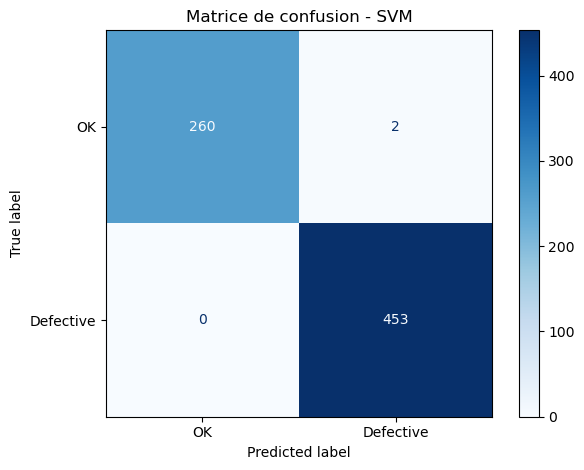

In [5]:
y_pred = model.predict(X_test)

metrics = compute_metrics(y_test, y_pred)
report_df = classification_report_dataframe(y_test, y_pred)

display(pd.DataFrame([metrics]))
display(report_df)

save_metrics(metrics, METRICS_DIR / "svm_metrics.json")
save_dataframe(report_df, METRICS_DIR / "svm_classification_report.csv")
plot_confusion_matrix(y_test, y_pred, "Matrice de confusion - SVM", FIGURES_DIR / "svm_confusion_matrix.png")

## Conclusion

Le SVM apprend une séparation à partir de plusieurs caractéristiques. Il peut capter des combinaisons que les règles manuelles ne voient pas directement.